In [1]:
# Libraries
import caveclient
import subprocess
import json
import numpy as np
import matplotlib.pyplot as plt
# Setup caveclient
client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr", ) #server_address='https://global.daf-apis.com')

In [2]:
exn_tag = client.materialize.query_table('spinalcord_neuron_clusters_2')

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [4]:
set(exn_tag['tag'])

{'adltmr_module',
 'cltmr_module',
 'noci_module',
 'np_module',
 'p1',
 'p2_cold',
 'p2_noci',
 'p2_poly',
 'r',
 'v1',
 'v2'}

In [2]:
# ============================================================
# Correct SWC exporter from exn_tag
#
# Input dataframe:
#   exn_tag
#
# Required columns:
#   pt_root_id
#   pt_position   # [x, y, z] in CAVE voxels
#   tag
#
# SWC types:
#   1 = soma/root
#   2 = axon
#   3 = dendrite
# ============================================================

from pathlib import Path
from typing import Sequence, List, Dict, Any
from collections import deque

import ast
import re
import sys

import numpy as np
import pandas as pd

import caveclient
import pcg_skel


# ============================================================
# Configuration
# ============================================================

DATASTACK = "wclee_mouse_spinalcord_cltmr"

# CAVE pt_position resolution
RES_NM_PER_PX = np.array(
    [32.0, 32.0, 45.0],
    dtype=float,
)

SOMA_COLLAPSE_RADIUS_NM = 7500
AXON_QUALITY_THRESH = 0.105
DEFAULT_RADIUS_NM = 1000.0

# Save coordinates in true nanometers
SWC_UNITS = "nm"

BASE_OUTDIR = Path(
    "/Users/wangchu/mesh_analysis/swc_by_tag_corrected"
)

SELECTED_TAGS = [
    "adltmr_module",
    "cltmr_module",
    "noci_module",
    "np_module",
    "p1",
    "p2_cold",
    "p2_noci",
    "p2_poly",
    "r",
    "v1",
    "v2",
]

# True: regenerate existing files
# False: skip existing nonempty files
OVERWRITE = False


# ============================================================
# Basic helpers
# ============================================================

def sanitize_label(label: Any) -> str:
    """Make a label safe to use as a folder name."""
    if pd.isna(label):
        label = "NA"

    label = str(label).strip()
    label = re.sub(r'[\\/:*?"<>|]', "_", label)
    label = re.sub(r"\s+", "_", label)

    return label if label else "NA"


def coerce_xyz(value: Any) -> np.ndarray:
    """
    Convert pt_position into a float array of shape (3,).

    Handles:
        [1, 2, 3]
        np.array([1, 2, 3])
        "[1, 2, 3]"
    """
    if isinstance(value, str):
        value = ast.literal_eval(value)

    xyz = np.asarray(value, dtype=float).ravel()

    if xyz.size != 3:
        raise ValueError(
            f"pt_position must contain exactly three values; got {xyz}"
        )

    return xyz


def px_to_nm(
    xyz_px: Sequence[float],
    resolution_nm_per_px: Sequence[float],
) -> np.ndarray:
    """Convert CAVE voxel coordinates to physical nanometers."""
    return (
        np.asarray(xyz_px, dtype=float)
        * np.asarray(resolution_nm_per_px, dtype=float)
    )


# ============================================================
# Build SWC parent pointers
# ============================================================

def compute_parent_array(
    n_vertices: int,
    edges: np.ndarray,
    root_idx: int,
) -> np.ndarray:
    """
    Orient an undirected skeleton tree away from root_idx.

    Returns
    -------
    parent : np.ndarray
        parent[i] is the zero-based parent index of node i.
        The root has parent -1.
    """
    edges = np.asarray(edges, dtype=int)

    adjacency = [[] for _ in range(n_vertices)]

    for node_a, node_b in edges:
        adjacency[node_a].append(node_b)
        adjacency[node_b].append(node_a)

    parent = np.full(
        n_vertices,
        -2,
        dtype=int,
    )

    parent[root_idx] = -1

    queue = deque([root_idx])

    while queue:
        current = queue.popleft()

        for neighbor in adjacency[current]:
            if parent[neighbor] == -2:
                parent[neighbor] = current
                queue.append(neighbor)

    # In case the skeleton contains disconnected islands,
    # make each unvisited island node a root.
    parent[parent == -2] = -1

    return parent


# ============================================================
# Project axon annotation onto skeleton
# ============================================================

def project_is_axon_to_skeleton(
    neuron_meshwork,
    skeleton,
) -> np.ndarray:
    """
    Convert mesh-level is_axon annotation into SWC type labels.

    Returns
    -------
    compartment : np.ndarray
        2 = axon
        3 = dendrite/default
    """
    if getattr(skeleton, "mesh_index", None) is None:
        raise ValueError(
            "The skeleton has no mesh_index mapping."
        )

    if not hasattr(neuron_meshwork, "anno"):
        raise ValueError(
            "Meshwork has no annotation object."
        )

    if not hasattr(neuron_meshwork.anno, "is_axon"):
        raise ValueError(
            "Meshwork has no is_axon annotation."
        )

    annotation_df = neuron_meshwork.anno.is_axon.df

    if "mesh_index" in annotation_df.columns:
        mesh_column = "mesh_index"
    elif "mesh_ind" in annotation_df.columns:
        mesh_column = "mesh_ind"
    else:
        raise ValueError(
            "is_axon annotation has neither "
            "'mesh_index' nor 'mesh_ind'."
        )

    axon_mesh_indices = np.asarray(
        annotation_df[mesh_column],
        dtype=np.int64,
    )

    skeleton_mesh_indices = np.asarray(
        skeleton.mesh_index,
        dtype=np.int64,
    )

    # Default all non-axon nodes to dendrite.
    compartment = np.full(
        len(skeleton_mesh_indices),
        3,
        dtype=int,
    )

    compartment[
        np.isin(
            skeleton_mesh_indices,
            axon_mesh_indices,
        )
    ] = 2

    return compartment


# ============================================================
# Generate skeleton and axon/dendrite labels
# ============================================================

def build_neuron_with_is_axon(
    client,
    root_id: int,
    soma_px: Sequence[float],
    *,
    resolution_nm_per_px: Sequence[float],
    collapse_radius_nm: int,
    axon_quality_threshold: float,
):
    """
    Build the neuron skeleton and classify axon versus dendrite.

    Important
    ---------
    soma_px is exn_tag['pt_position'] in CAVE voxel coordinates.

    root_point_resolution tells pcg_skel how to interpret soma_px.
    """

    soma_px = tuple(
        float(value)
        for value in soma_px
    )

    skeleton, mesh, l2dict = pcg_skel.pcg_skeleton(
        root_id,
        client,
        return_mesh=True,

        # Soma point is in voxels
        root_point=soma_px,
        root_point_resolution=tuple(
            float(value)
            for value in resolution_nm_per_px
        ),

        collapse_soma=True,
        collapse_radius=int(collapse_radius_nm),
        return_l2dict=True,
    )

    neuron_meshwork = pcg_skel.pcg_meshwork(
        root_id=root_id,
        client=client,

        # Again, point is in voxels
        root_point=soma_px,
        root_point_resolution=tuple(
            float(value)
            for value in resolution_nm_per_px
        ),

        collapse_soma=True,
        collapse_radius=int(collapse_radius_nm),
        synapses=True,
    )

    pcg_skel.features.add_synapse_count(
        neuron_meshwork
    )

    pcg_skel.features.add_is_axon_annotation(
        neuron_meshwork,
        pre_anno="pre_syn",
        post_anno="post_syn",
        annotation_name="is_axon",
        return_quality=True,
        threshold_quality=float(
            axon_quality_threshold
        ),
    )

    compartment = project_is_axon_to_skeleton(
        neuron_meshwork,
        skeleton,
    )

    return skeleton, neuron_meshwork, compartment


# ============================================================
# Write one corrected SWC
# ============================================================

def skeleton_to_correct_swc(
    skeleton,
    compartment: np.ndarray,
    soma_px: Sequence[float],
    output_path: Path,
    *,
    resolution_nm_per_px: Sequence[float],
    units: str = "nm",
    default_radius_nm: float = 1000.0,
) -> Dict[str, Any]:
    """
    Write one SWC with correctly scaled coordinates and soma.

    Important
    ---------
    pcg_skel skeleton vertices are treated as already being in nm.

    The CAVE soma point is supplied in voxels and is converted to nm
    before finding its nearest skeleton vertex.
    """

    # pcg_skel vertices are already physical coordinates in nm.
    vertices_nm = np.asarray(
        skeleton.vertices,
        dtype=float,
    )

    edges = np.asarray(
        skeleton.edges,
        dtype=int,
    )

    n_vertices = len(vertices_nm)

    if n_vertices == 0:
        raise ValueError(
            "Skeleton contains no vertices."
        )

    if len(compartment) != n_vertices:
        raise ValueError(
            "Compartment-label length does not match "
            "the number of skeleton vertices."
        )

    # Convert CAVE pt_position from voxels to nm.
    soma_px = np.asarray(
        soma_px,
        dtype=float,
    ).reshape(3)

    soma_nm = px_to_nm(
        soma_px,
        resolution_nm_per_px,
    )

    # Find the skeleton vertex physically nearest to the CAVE soma point.
    displacement_nm = (
        vertices_nm
        - soma_nm.reshape(1, 3)
    )

    distance_nm = np.linalg.norm(
        displacement_nm,
        axis=1,
    )

    root_idx = int(
        np.argmin(distance_nm)
    )

    root_distance_nm = float(
        distance_nm[root_idx]
    )

    # Root the parent tree at the selected soma vertex.
    parent = compute_parent_array(
        n_vertices=n_vertices,
        edges=edges,
        root_idx=root_idx,
    )

    # Start with axon/dendrite labels.
    node_types = np.asarray(
        compartment,
        dtype=int,
    ).copy()

    original_root_type = int(
        node_types[root_idx]
    )

    # Mark only the closest soma/root node as type 1.
    node_types[root_idx] = 1

    # Choose output units.
    if units == "nm":
        coordinates = vertices_nm

        radii = np.full(
            n_vertices,
            float(default_radius_nm),
            dtype=float,
        )

    elif units == "um":
        coordinates = vertices_nm / 1000.0

        radii = np.full(
            n_vertices,
            float(default_radius_nm) / 1000.0,
            dtype=float,
        )

    elif units == "px":
        coordinates = (
            vertices_nm
            / np.asarray(
                resolution_nm_per_px,
                dtype=float,
            ).reshape(1, 3)
        )

        average_resolution = float(
            np.mean(resolution_nm_per_px)
        )

        radii = np.full(
            n_vertices,
            float(default_radius_nm)
            / average_resolution,
            dtype=float,
        )

    else:
        raise ValueError(
            "units must be 'nm', 'um', or 'px'."
        )

    output_path = Path(output_path)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    header = [
        "# Corrected pcg_skel SWC export",
        f"# Units: {units}",
        (
            "# Resolution (nm/px): "
            f"{tuple(float(x) for x in resolution_nm_per_px)}"
        ),
        (
            "# CAVE soma pt_position (px): "
            f"{tuple(float(x) for x in soma_px)}"
        ),
        (
            "# CAVE soma physical position (nm): "
            f"{tuple(float(x) for x in soma_nm)}"
        ),
        (
            "# Selected soma skeleton position (nm): "
            f"{tuple(float(x) for x in vertices_nm[root_idx])}"
        ),
        (
            "# Distance from CAVE soma to selected "
            f"skeleton node (nm): {root_distance_nm:.3f}"
        ),
        (
            "# Selected node compartment before soma override: "
            f"{original_root_type}"
        ),
        "# Columns: n type x y z radius parent",
        "# Type: 1=soma, 2=axon, 3=dendrite",
    ]

    with output_path.open("w") as file:
        file.write(
            "\n".join(header) + "\n"
        )

        for index in range(n_vertices):
            swc_node_id = index + 1
            node_type = int(node_types[index])

            x, y, z = coordinates[index]
            radius = float(radii[index])

            if parent[index] >= 0:
                parent_swc_id = int(
                    parent[index]
                ) + 1
            else:
                parent_swc_id = -1

            file.write(
                f"{swc_node_id} "
                f"{node_type} "
                f"{x:.3f} "
                f"{y:.3f} "
                f"{z:.3f} "
                f"{radius:.3f} "
                f"{parent_swc_id}\n"
            )

    return {
        "output_path": str(output_path),
        "root_idx_zero_based": root_idx,
        "root_swc_node_id": root_idx + 1,
        "root_distance_nm": root_distance_nm,
        "root_distance_um": root_distance_nm / 1000.0,
        "root_original_type": original_root_type,
        "soma_px_x": soma_px[0],
        "soma_px_y": soma_px[1],
        "soma_px_z": soma_px[2],
        "soma_nm_x": soma_nm[0],
        "soma_nm_y": soma_nm[1],
        "soma_nm_z": soma_nm[2],
        "selected_soma_nm_x": vertices_nm[root_idx, 0],
        "selected_soma_nm_y": vertices_nm[root_idx, 1],
        "selected_soma_nm_z": vertices_nm[root_idx, 2],
    }


# ============================================================
# Export one neuron
# ============================================================

def export_one_neuron(
    client,
    root_id: int,
    soma_px: Sequence[float],
    output_path: Path,
) -> Dict[str, Any]:
    """Generate and save one corrected SWC."""

    skeleton, neuron_meshwork, compartment = (
        build_neuron_with_is_axon(
            client=client,
            root_id=int(root_id),
            soma_px=soma_px,
            resolution_nm_per_px=RES_NM_PER_PX,
            collapse_radius_nm=SOMA_COLLAPSE_RADIUS_NM,
            axon_quality_threshold=AXON_QUALITY_THRESH,
        )
    )

    result = skeleton_to_correct_swc(
        skeleton=skeleton,
        compartment=compartment,
        soma_px=soma_px,
        output_path=output_path,
        resolution_nm_per_px=RES_NM_PER_PX,
        units=SWC_UNITS,
        default_radius_nm=DEFAULT_RADIUS_NM,
    )

    result["root_id"] = int(root_id)

    return result

In [3]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import caveclient


# ============================================================
# Configuration
# ============================================================

SOMA_CSV = "superficial_in_soma_volume_15um_updated.csv"

OUTPUT_DIR = Path(
    "/Users/wangchu/mesh_analysis/lamian_i_in"
)

DATASTACK = "wclee_mouse_spinalcord_cltmr"

# False: preserve existing nonempty SWC files
# True: regenerate and overwrite them
OVERWRITE = False


# ============================================================
# Load soma table
# ============================================================

soma_df = pd.read_csv(
    SOMA_CSV,
    dtype={"root_id": "string"},
    low_memory=False,
)

required_columns = {
    "root_id",
    "pt_position",
    "tag",
}

missing_columns = required_columns - set(soma_df.columns)

if missing_columns:
    raise KeyError(
        "The soma CSV is missing required columns: "
        f"{sorted(missing_columns)}"
    )


# ============================================================
# Normalize fields
# ============================================================

soma_df["tag_normalized"] = (
    soma_df["tag"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

soma_df["root_id_numeric"] = pd.to_numeric(
    soma_df["root_id"],
    errors="coerce",
)


# ============================================================
# Select lamina I interneurons
#
# p = projection neuron
# o = partial neuron
# everything else = interneuron
# ============================================================

interneuron_df = soma_df.loc[
    (soma_df["tag_normalized"] != "p")
    & (soma_df["tag_normalized"] != "o")
    & soma_df["root_id_numeric"].notna()
    & soma_df["pt_position"].notna(),
    [
        "root_id_numeric",
        "pt_position",
        "tag",
        "tag_normalized",
    ],
].copy()

interneuron_df["root_id_numeric"] = (
    interneuron_df["root_id_numeric"]
    .astype("int64")
)

# One SWC per root ID
interneuron_df = (
    interneuron_df
    .drop_duplicates(
        subset="root_id_numeric",
        keep="last",
    )
    .sort_values("root_id_numeric")
    .reset_index(drop=True)
)

print(
    f"Selected {len(interneuron_df)} "
    "lamina I interneurons."
)

print("\nCounts by original tag:")
print(
    interneuron_df["tag_normalized"]
    .value_counts(dropna=False)
)


# ============================================================
# Prepare output folder and CAVE client
# ============================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

client = caveclient.CAVEclient(
    DATASTACK
)


# ============================================================
# Export all interneurons
# ============================================================

export_results = []
export_errors = []

for row_number, row in interneuron_df.iterrows():

    root_id = int(
        row["root_id_numeric"]
    )

    swc_path = (
        OUTPUT_DIR
        / f"{root_id}.swc"
    )

    print(
        f"\n[{row_number + 1}/{len(interneuron_df)}] "
        f"Processing {root_id}"
    )

    try:
        soma_px = coerce_xyz(
            row["pt_position"]
        )

        # Preserve an existing valid file unless overwrite is requested.
        if (
            not OVERWRITE
            and swc_path.exists()
            and swc_path.stat().st_size > 0
        ):
            export_results.append({
                "root_id": root_id,
                "tag": row["tag"],
                "status": "existing",
                "output_path": str(swc_path),
            })

            print(
                f"[existing] {root_id}"
            )

            continue

        result = export_one_neuron(
            client=client,
            root_id=root_id,
            soma_px=soma_px,
            output_path=swc_path,
        )

        result.update({
            "tag": row["tag"],
            "status": "exported",
        })

        export_results.append(
            result
        )

        print(
            f"[exported] {root_id} | "
            f"soma distance = "
            f"{result['root_distance_um']:.2f} µm"
        )

    except Exception as error:
        export_errors.append({
            "root_id": root_id,
            "tag": row["tag"],
            "pt_position": row["pt_position"],
            "output_path": str(swc_path),
            "error_type": type(error).__name__,
            "error": str(error),
        })

        print(
            f"[error] {root_id}: "
            f"{type(error).__name__}: {error}",
            file=sys.stderr,
        )


# ============================================================
# Save quality-control tables
# ============================================================

export_results_df = pd.DataFrame(
    export_results
)

export_errors_df = pd.DataFrame(
    export_errors
)

qc_path = (
    OUTPUT_DIR
    / "lamina_i_interneuron_swc_qc.csv"
)

error_path = (
    OUTPUT_DIR
    / "lamina_i_interneuron_swc_errors.csv"
)

export_results_df.to_csv(
    qc_path,
    index=False,
)

export_errors_df.to_csv(
    error_path,
    index=False,
)


# ============================================================
# Summary
# ============================================================

print("\n========================================")
print("Lamina I interneuron export complete")
print("========================================")

print(
    f"Selected neurons: {len(interneuron_df)}"
)

print(
    f"Exported or already existing: "
    f"{len(export_results_df)}"
)

print(
    f"Errors: {len(export_errors_df)}"
)

print(
    f"\nSWC output folder:\n{OUTPUT_DIR}"
)

print(
    f"\nQC table:\n{qc_path}"
)

if not export_errors_df.empty:
    print(
        f"\nError table:\n{error_path}"
    )

    display(
        export_errors_df
    )

Selected 417 lamina I interneurons.

Counts by original tag:
tag_normalized
v     252
u     155
c1      5
r       5
Name: count, dtype: int64

[1/417] Processing 720575940851285875


/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/pcg_skel/features.py:444: UserWarning: Split quality below threshold, no axon mesh vertices added!
  warn("Split quality below threshold, no axon mesh vertices added!")


[exported] 720575940851285875 | soma distance = 0.00 µm

[2/417] Processing 720575940851357043


/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/pcg_skel/features.py:444: UserWarning: Split quality below threshold, no axon mesh vertices added!
  warn("Split quality below threshold, no axon mesh vertices added!")


[exported] 720575940851357043 | soma distance = 0.00 µm

[3/417] Processing 720575940851388531


...

/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/pcg_skel/features.py:444: UserWarning: Split quality below threshold, no axon mesh vertices added!
  warn("Split quality below threshold, no axon mesh vertices added!")


[exported] 720575940964284070 | soma distance = 0.00 µm

[417/417] Processing 720575940964298406


[exported] 720575940964298406 | soma distance = 0.00 µm

Lamina I interneuron export complete
Selected neurons: 417
Exported or already existing: 412
Errors: 5

SWC output folder:
/Users/wangchu/mesh_analysis/lamian_i_in

QC table:
/Users/wangchu/mesh_analysis/lamian_i_in/lamina_i_interneuron_swc_qc.csv

Error table:
/Users/wangchu/mesh_analysis/lamian_i_in/lamina_i_interneuron_swc_errors.csv


/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/pcg_skel/features.py:444: UserWarning: Split quality below threshold, no axon mesh vertices added!
  warn("Split quality below threshold, no axon mesh vertices added!")


,root_id,tag,pt_position,output_path,error_type,error
0,720575940881500611,v,"[7380, 3043, 2208]",/Users/wangchu/mesh_analysis/lamian_i_in/72057...,SSLError,"HTTPSConnectionPool(host='cave.fanc-fly.com', ..."
1,720575940881545155,u,"[36262, 2356, 3211]",/Users/wangchu/mesh_analysis/lamian_i_in/72057...,SSLError,"HTTPSConnectionPool(host='cave.fanc-fly.com', ..."
2,720575940881619651,u,"[29180, 2401, 1837]",/Users/wangchu/mesh_analysis/lamian_i_in/72057...,SSLError,"HTTPSConnectionPool(host='cave.fanc-fly.com', ..."
3,720575940881709136,v,"[13550, 2764, 3652]",/Users/wangchu/mesh_analysis/lamian_i_in/72057...,SSLError,"HTTPSConnectionPool(host='cave.fanc-fly.com', ..."
4,720575940881720656,u,"[25754, 2352, 3810]",/Users/wangchu/mesh_analysis/lamian_i_in/72057...,SSLError,"HTTPSConnectionPool(host='cave.fanc-fly.com', ..."


In [7]:
# ============================================================
# Validate exn_tag
# ============================================================

required_columns = {
    "pt_root_id",
    "pt_position",
    "tag",
}

missing_columns = (
    required_columns
    - set(exn_tag.columns)
)

if missing_columns:
    raise KeyError(
        "exn_tag is missing required columns: "
        f"{sorted(missing_columns)}"
    )


# ============================================================
# Filter selected tags
# ============================================================

selected_tag_lookup = {
    tag.strip().lower(): tag
    for tag in SELECTED_TAGS
}

normalized_tags = (
    exn_tag["tag"]
    .astype(str)
    .str.strip()
    .str.lower()
)

selected_mask = normalized_tags.isin(
    selected_tag_lookup
)

export_table = exn_tag.loc[
    selected_mask,
    [
        "pt_root_id",
        "pt_position",
        "tag",
    ],
].copy()

# Drop duplicate root IDs within the same tag.
export_table["_tag_normalized"] = (
    export_table["tag"]
    .astype(str)
    .str.strip()
    .str.lower()
)

export_table = export_table.drop_duplicates(
    subset=[
        "pt_root_id",
        "_tag_normalized",
    ],
    keep="last",
)

print(
    f"Selected {len(export_table)} rows "
    f"across {export_table['_tag_normalized'].nunique()} tags."
)

print("\nCounts by tag:")
print(
    export_table["_tag_normalized"]
    .value_counts()
    .reindex(SELECTED_TAGS)
)


# ============================================================
# Export all neurons by tag
# ============================================================

BASE_OUTDIR.mkdir(
    parents=True,
    exist_ok=True,
)

client = caveclient.CAVEclient(
    DATASTACK
)

export_results = []
export_errors = []

for _, row in export_table.iterrows():

    root_id = int(
        row["pt_root_id"]
    )

    normalized_tag = str(
        row["_tag_normalized"]
    )

    output_tag = selected_tag_lookup[
        normalized_tag
    ]

    folder_name = sanitize_label(
        output_tag
    )

    tag_output_directory = (
        BASE_OUTDIR
        / folder_name
    )

    tag_output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    swc_path = (
        tag_output_directory
        / f"{root_id}.swc"
    )

    try:
        soma_px = coerce_xyz(
            row["pt_position"]
        )

        if (
            not OVERWRITE
            and swc_path.exists()
            and swc_path.stat().st_size > 0
        ):
            export_results.append({
                "root_id": root_id,
                "tag": output_tag,
                "status": "existing",
                "output_path": str(swc_path),
            })

            print(
                f"[existing] {output_tag}: "
                f"{root_id}"
            )

            continue

        result = export_one_neuron(
            client=client,
            root_id=root_id,
            soma_px=soma_px,
            output_path=swc_path,
        )

        result.update({
            "tag": output_tag,
            "status": "exported",
        })

        export_results.append(
            result
        )

        print(
            f"[exported] {output_tag}: {root_id} | "
            f"soma distance = "
            f"{result['root_distance_um']:.2f} µm | "
            f"original compartment = "
            f"{result['root_original_type']}"
        )

    except Exception as error:
        export_errors.append({
            "root_id": root_id,
            "tag": output_tag,
            "pt_position": row["pt_position"],
            "output_path": str(swc_path),
            "error": str(error),
        })

        print(
            f"[error] {output_tag}: "
            f"{root_id} — {error}",
            file=sys.stderr,
        )


# ============================================================
# Results and quality-control tables
# ============================================================

export_results_df = pd.DataFrame(
    export_results
)

export_errors_df = pd.DataFrame(
    export_errors
)

print("\n========================================")
print("Export complete")
print("========================================")

print(
    f"Successful/existing: "
    f"{len(export_results_df)}"
)

print(
    f"Errors: "
    f"{len(export_errors_df)}"
)

if not export_results_df.empty:
    print("\nStatus by tag:")

    print(
        export_results_df.groupby(
            ["tag", "status"]
        ).size()
    )

    if "root_distance_um" in export_results_df.columns:
        print(
            "\nDistance from CAVE soma point "
            "to selected skeleton node:"
        )

        print(
            export_results_df[
                "root_distance_um"
            ].describe()
        )

        print(
            "\nLargest soma-point mismatches:"
        )

        display_columns = [
            "root_id",
            "tag",
            "root_distance_um",
            "root_original_type",
            "output_path",
        ]

        display(
            export_results_df.sort_values(
                "root_distance_um",
                ascending=False,
            )[display_columns].head(20)
        )

if not export_errors_df.empty:
    print("\nExport errors:")

    display(
        export_errors_df
    )


# Save QC results
qc_output_path = (
    BASE_OUTDIR
    / "swc_export_quality_control.csv"
)

export_results_df.to_csv(
    qc_output_path,
    index=False,
)

print(
    f"\nQuality-control table saved to:\n"
    f"{qc_output_path}"
)

Selected 223 rows across 11 tags.

Counts by tag:
_tag_normalized
adltmr_module    15
cltmr_module     24
noci_module      10
np_module        27
p1                6
p2_cold           9
p2_noci          16
p2_poly          15
r                24
v1               41
v2               36
Name: count, dtype: int64
[existing] p2_noci: 720575940865160474
[existing] p2_noci: 720575940881844049
[existing] p2_noci: 720575940902401208
[existing] p2_noci: 720575940896702138
[existing] p2_noci: 720575940898432765
[existing] p2_noci: 720575940888731665
[existing] p2_noci: 720575940879773686
[existing] p2_noci: 720575940884939979
[existing] p2_noci: 720575940880850833
[existing] p2_noci: 720575940915676096
[existing] p2_noci: 720575940895281326
[existing] p2_noci: 720575940894563284
[existing] p2_noci: 720575940898821041
[existing] p2_cold: 720575940884015788
[existing] p2_poly: 720575940889967848
[existing] p2_poly: 720575940881974650
[existing] p2_poly: 720575940890018996
[existing] p2_noci: 72057

[exported] v1: 720575940920037245 | soma distance = 0.00 µm | original compartment = 3


[exported] v1: 720575940891185846 | soma distance = 0.00 µm | original compartment = 3


[exported] v1: 720575940937894317 | soma distance = 0.00 µm | original compartment = 3


[exported] v1: 720575940878957108 | soma distance = 0.00 µm | original compartment = 3


...

[exported] r: 720575940920080765 | soma distance = 0.00 µm | original compartment = 3


[exported] r: 720575940920456848 | soma distance = 0.00 µm | original compartment = 3


[exported] r: 720575940928343548 | soma distance = 0.00 µm | original compartment = 3
[existing] r: 720575940937857965
[existing] r: 720575940877555511
[existing] r: 720575940917852811
[existing] r: 720575940902629074
[existing] r: 720575940888799761
[existing] r: 720575940871589433
[existing] r: 720575940921583379
[existing] r: 720575940905042902
[existing] r: 720575940905043670
[existing] r: 720575940905043926
[existing] r: 720575940884057772
[existing] r: 720575940908782425
[existing] r: 720575940903188925
[existing] r: 720575940946223236
[existing] r: 720575940894664404
[existing] r: 720575940903415565
[existing] r: 720575940875854397
[existing] r: 720575940910295881
[existing] r: 720575940884925028

Export complete
Successful/existing: 223
Errors: 0

Status by tag:
tag            status  
adltmr_module  existing    15
cltmr_module   existing    24
noci_module    existing    10
np_module      existing    27
p1             existing     6
p2_cold        existing     9
p2_noci        

,root_id,tag,root_distance_um,root_original_type,output_path
191,720575940920037245,v1,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...
192,720575940891185846,v1,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...
193,720575940937894317,v1,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...
194,720575940878957108,v1,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...
195,720575940900033476,v1,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...
196,720575940919632133,v1,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...
197,720575940917853067,v1,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...
198,720575940892205566,v1,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...
199,720575940890962241,r,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...
200,720575940883201751,r,0.0,3.0,/Users/wangchu/mesh_analysis/swc_by_tag_correc...



Quality-control table saved to:
/Users/wangchu/mesh_analysis/swc_by_tag_corrected/swc_export_quality_control.csv


SWC path:
/Users/wangchu/mesh_analysis/swc_by_tag_corrected/v1/720575940920037245.swc

Node counts:
type
axon        652
dendrite    365
soma          1
Name: count, dtype: int64

Root nodes:
         n  type        x       y       z type_name
1017  1018     1  909.696  100.96  76.545      soma

Soma node:
         n        x       y       z  parent
1017  1018  909.696  100.96  76.545      -1

Coordinate ranges in µm:
            x        y       z
min   595.872   84.768    4.77
max  1492.672  396.160  100.62

Spatial spreads in µm:
x    896.800
y    311.392
z     95.850
dtype: float64


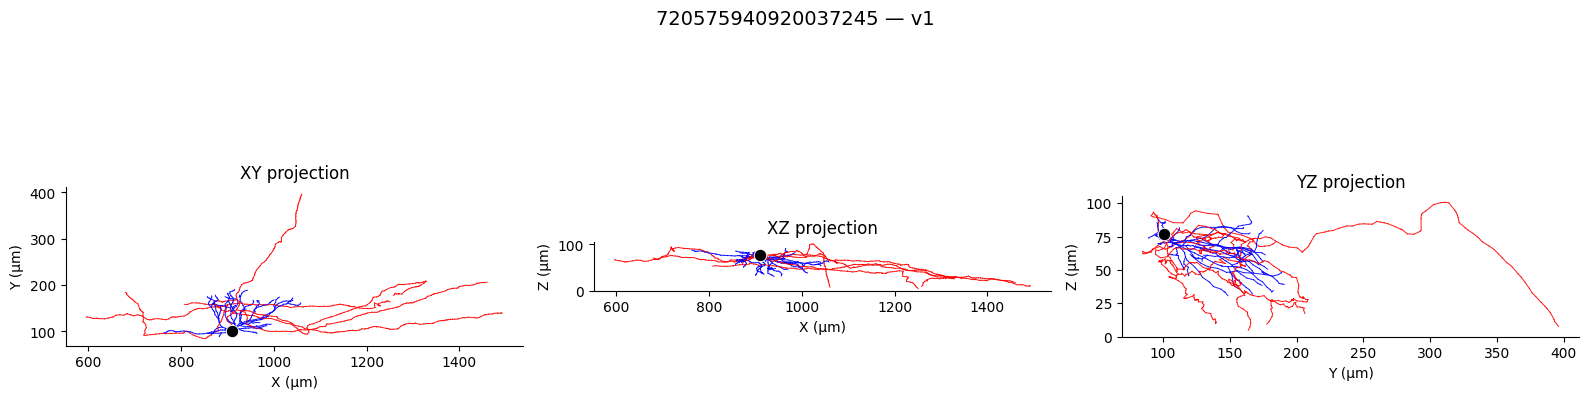

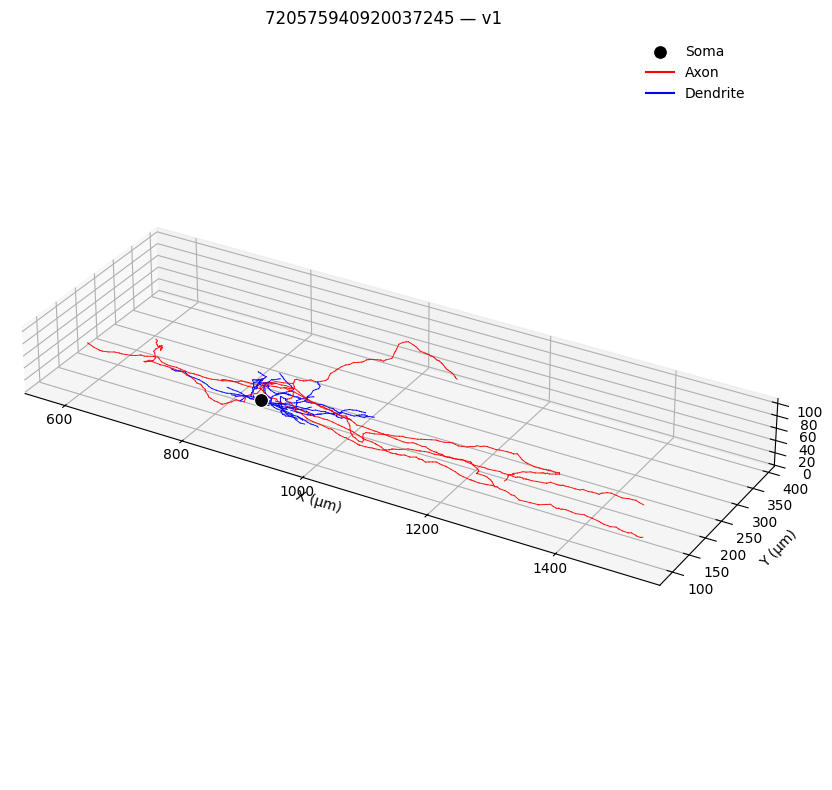

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

ROOT_ID = "720575940920037245"

SWC_PATH = (
    Path("/Users/wangchu/mesh_analysis/swc_by_tag_corrected")
    / "v1"
    / f"{ROOT_ID}.swc"
)

# Plot coordinates in µm.
# The corrected SWCs are saved in true nm.
COORDINATE_SCALE = 1 / 1000.0


# ============================================================
# Load SWC
# ============================================================

def load_swc_df(path):
    columns = [
        "n",
        "type",
        "x",
        "y",
        "z",
        "radius",
        "parent",
    ]

    return pd.read_csv(
        path,
        comment="#",
        sep=r"\s+",
        engine="python",
        header=None,
        names=columns,
        dtype={
            "n": int,
            "type": int,
            "x": float,
            "y": float,
            "z": float,
            "radius": float,
            "parent": int,
        },
    )


if not SWC_PATH.exists():
    raise FileNotFoundError(
        f"Could not find:\n{SWC_PATH}"
    )

swc = load_swc_df(SWC_PATH)

# Convert nm to µm for plotting.
swc[["x", "y", "z", "radius"]] *= COORDINATE_SCALE

node_lookup = swc.set_index("n")


# ============================================================
# Basic quality-control summary
# ============================================================

type_names = {
    1: "soma",
    2: "axon",
    3: "dendrite",
}

print("SWC path:")
print(SWC_PATH)

print("\nNode counts:")
print(
    swc["type"]
    .map(type_names)
    .value_counts()
)

roots = swc.loc[
    swc["parent"] == -1,
    ["n", "type", "x", "y", "z"],
].copy()

roots["type_name"] = roots["type"].map(type_names)

print("\nRoot nodes:")
print(roots)

soma = swc.loc[
    swc["type"] == 1,
    ["n", "x", "y", "z", "parent"],
].copy()

print("\nSoma node:")
print(soma)

print("\nCoordinate ranges in µm:")
print(
    swc[["x", "y", "z"]].agg(
        ["min", "max"]
    )
)

print("\nSpatial spreads in µm:")
print(
    swc[["x", "y", "z"]].max()
    - swc[["x", "y", "z"]].min()
)


# ============================================================
# Plot helpers
# ============================================================

TYPE_COLORS = {
    1: "black",
    2: "red",
    3: "blue",
}

TYPE_LINEWIDTHS = {
    1: 1.5,
    2: 0.7,
    3: 0.7,
}


def draw_projection(
    ax,
    x_column,
    y_column,
    x_label,
    y_label,
):
    """
    Draw every SWC edge, colored by the child node's type.
    """
    for _, child in swc.iterrows():
        parent_id = int(child["parent"])

        if parent_id == -1:
            continue

        if parent_id not in node_lookup.index:
            continue

        parent = node_lookup.loc[parent_id]

        node_type = int(child["type"])

        ax.plot(
            [
                parent[x_column],
                child[x_column],
            ],
            [
                parent[y_column],
                child[y_column],
            ],
            color=TYPE_COLORS.get(
                node_type,
                "gray",
            ),
            linewidth=TYPE_LINEWIDTHS.get(
                node_type,
                0.6,
            ),
            alpha=0.9,
        )

    # Soma as a large black point.
    soma_rows = swc.loc[
        swc["type"] == 1
    ]

    ax.scatter(
        soma_rows[x_column],
        soma_rows[y_column],
        s=80,
        color="black",
        edgecolor="white",
        linewidth=0.7,
        zorder=10,
        label="Soma",
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ============================================================
# Plot three 2D projections
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

draw_projection(
    axes[0],
    "x",
    "y",
    "X (µm)",
    "Y (µm)",
)
axes[0].set_title("XY projection")

draw_projection(
    axes[1],
    "x",
    "z",
    "X (µm)",
    "Z (µm)",
)
axes[1].set_title("XZ projection")

draw_projection(
    axes[2],
    "y",
    "z",
    "Y (µm)",
    "Z (µm)",
)
axes[2].set_title("YZ projection")

fig.suptitle(
    f"{ROOT_ID} — v1",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# ============================================================
# 3D plot
# ============================================================

fig = plt.figure(
    figsize=(9, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d",
)

for _, child in swc.iterrows():
    parent_id = int(child["parent"])

    if parent_id == -1:
        continue

    if parent_id not in node_lookup.index:
        continue

    parent = node_lookup.loc[parent_id]
    node_type = int(child["type"])

    ax.plot(
        [
            parent["x"],
            child["x"],
        ],
        [
            parent["y"],
            child["y"],
        ],
        [
            parent["z"],
            child["z"],
        ],
        color=TYPE_COLORS.get(
            node_type,
            "gray",
        ),
        linewidth=TYPE_LINEWIDTHS.get(
            node_type,
            0.6,
        ),
        alpha=0.9,
    )

soma_rows = swc.loc[
    swc["type"] == 1
]

ax.scatter(
    soma_rows["x"],
    soma_rows["y"],
    soma_rows["z"],
    s=100,
    color="black",
    edgecolor="white",
    linewidth=0.8,
    label="Soma",
    zorder=10,
)

# Legend-only handles.
ax.plot(
    [],
    [],
    [],
    color="red",
    label="Axon",
)

ax.plot(
    [],
    [],
    [],
    color="blue",
    label="Dendrite",
)

ax.set_xlabel("X (µm)")
ax.set_ylabel("Y (µm)")
ax.set_zlabel("Z (µm)")
ax.set_title(f"{ROOT_ID} — v1")

# Physical equal aspect ratio.
x_range = swc["x"].max() - swc["x"].min()
y_range = swc["y"].max() - swc["y"].min()
z_range = swc["z"].max() - swc["z"].min()

ax.set_box_aspect(
    (
        max(x_range, 1e-9),
        max(y_range, 1e-9),
        max(z_range, 1e-9),
    )
)

ax.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

In [12]:
# Export lamina I interneuron skeleton
import numpy as np
import os
import matplotlib.pyplot as plt


# ---------- Configuration ----------
SEG_VOL_PATH = "graphene://https://cave.fanc-fly.com/segmentation/table/wclee_mouse_spinalcord_cltmr"
CACHE_DIR = "/Users/wangchu/connectivity_analysis/meshes"
RADIUS_THRESH = 20000  # in nanometers (15 µm radius for bounding box)
VOXEL_RES = [32, 32, 45]  # nanometers per voxel (assumed input resolution)
# -----------------------------------


import pandas as pd
import numpy as np
df = pd.read_csv('in_soma_coord.csv')

import cloudvolume
spinalcord_seg = cloudvolume.CloudVolume(SEG_VOL_PATH, 
                                   use_https=True,
                                   mip=(32,32,45), 
                                   agglomerate=True, # for rootids
                                   progress=False)

root_ids = []
results=[]
def get_seg_id_from_coord(coord, seg_mip=(32,32,45), coordinate_mip=(32,32,45)):

    mip_scale = np.array(seg_mip)/np.array(coordinate_mip)
    seg_coord = (coord[0]//mip_scale[0], coord[1]//mip_scale[1], coord[2]//mip_scale[2])
    
    voxel_seg_id = spinalcord_seg[seg_coord] # segmentation ID of neuron coordinate
    return voxel_seg_id

for idx, row in df.iterrows():
    coord_str = str(row['point'])  # Note: keeping the misspelling as it appears in the CSV
    try:
        # Parse coordinates, handling both integer and float formats
        coords = [float(x.strip()) for x in coord_str.split(',')]
        coords = [int(round(x)) for x in coords]  # Round and convert to integers
        print(coords)
        root_id = get_seg_id_from_coord(coords)
        root_ids.append(root_id)  # Add root_id to list (will include None values)
        
        if root_id is not None:
            results.append({
                'x': coords[0],
                'y': coords[1],
                'z': coords[2],
                'root_id': root_id
            })
            print(f"Processed coordinate {coords}: root_id = {root_id}")
        else:
            print(f"No root ID found for coordinate {coords}")
    except Exception as e:
        print(f"Error parsing coordinate string {coord_str}: {str(e)}")
        root_ids.append(None)  # Add None for failed coordinates

# Print all root IDs
print("\nAll root IDs (including None values):")
print(root_ids)
# Convert results to DataFrame and save
results_df = pd.DataFrame(results)

[29596, 2493, 816]
Processed coordinate [29596, 2493, 816]: root_id = [[[[720575940911002785]]]]
[29097, 2695, 754]
Processed coordinate [29097, 2695, 754]: root_id = [[[[720575940881910011]]]]
[28068, 2542, 754]
Processed coordinate [28068, 2542, 754]: root_id = [[[[720575940890634484]]]]
[27218, 2599, 760]
Processed coordinate [27218, 2599, 760]: root_id = [[[[720575940910500889]]]]
[26715, 2488, 1653]
Processed coordinate [26715, 2488, 1653]: root_id = [[[[720575940878957108]]]]
[24276, 2383, 1624]
Processed coordinate [24276, 2383, 1624]: root_id = [[[[720575940898475005]]]]
[23641, 2173, 1600]
Processed coordinate [23641, 2173, 1600]: root_id = [[[[720575940951332903]]]]
[21965, 2488, 1600]
Processed coordinate [21965, 2488, 1600]: root_id = [[[[720575940897341954]]]]
[21813, 2702, 1600]
Processed coordinate [21813, 2702, 1600]: root_id = [[[[720575940868451736]]]]
[16149, 2357, 1723]
Processed coordinate [16149, 2357, 1723]: root_id = [[[[720575940916299357]]]]
[15501, 2724, 1720

In [15]:
results = [
    ([row['x'], row['y'], row['z']], row['root_id'][0][0][0][0])
    for _, row in results_df.iterrows()
]
# Extract root IDs from results
root_ids = [
    int(item[1])
    for item in results
]

print(root_ids)

[720575940911002785, 720575940881910011, 720575940890634484, 720575940910500889, 720575940878957108, 720575940898475005, 720575940951332903, 720575940897341954, 720575940868451736, 720575940916299357, 720575940964211366, 720575940891064758, 720575940905042134, 720575940914015166, 720575940883648760, 720575940913573871, 720575940892204542, 720575940929449210, 720575940920454032, 720575940886125766, 720575940905011766, 720575940937248030, 720575940888780559, 720575940917107516, 720575940923615836, 720575940899566768, 720575940940334251, 720575940914015422, 720575940896738234, 720575940891184310, 720575940894634964, 720575940889201125, 720575940923000264, 720575940889695073, 720575940941132140, 720575940893107370, 720575940916017760, 720575940864426508, 720575940899566768, 720575940903408397, 720575940916017248, 720575940886268836, 720575940890028724, 720575940899779727, 720575940907504724, 720575940899191123, 720575940921262542, 720575940882119968, 720575940891187382, 720575940909125852,

In [16]:
len(root_ids)

51